#### In this analysis, we aim to evaluate the performance of different coffee cooperatives by analyzing key metrics related to coffee production. The primary objectives are to understand how different yield classes contribute to the overall coffee volume and the distribution of farmers across these classes. 

#### OBJECTIVES 
1. Assess Yield Distribution: Determine the distribution of coffee yield across various classes and understand the proportion of farmers and coffee volume within each yield class for different cooperatives.
2. Analyze Farmer Distribution: Evaluate the percentage of farmers falling into each yield class and how this distribution impacts the overall coffee production.
3. Measure Volume Contribution: Calculate and compare the contribution of each yield class to the total coffee volume produced by each cooperative.
4. Identify Performance Trends: Identify and compare trends in performance across cooperatives, highlighting areas of strength and potential improvement.

#### STEPS
1. DATA CLEANING: Checked and removed for all duplicates, and changed colunmn headings from French to English for better understanding
2. DATA INTEGRATION: All data were merged based on the unique column which is the Farmer Code
3. DATA PROCESSING: Data were processed one cooperation after the other starting from cooperative 1
4. YIELD CALCULATION: Yield were calculated by dividing the COH delivered volume in KG by the surface areas. Where surface area is not recorded in the mapping data, declared surface area from the cooperative registers were used to calculate the yield. 
5. RESULTS AND VISUALIZATION: Charts and table were produced to show distribution, volume and percentages of the yield in a given category of classes. Classes are [o to 400], [ 401 to 800], and [801 above ] representing under-delivering, normal delivering and over delivering respectively. A summary table is produced to show all the outcomes.
6. DISCUSSION AND COMMENTS: Some discussion, analysis and comments were made in the last chapter

In [18]:

#Import data
import pandas as pd
trace_data=pd.read_excel(r'C:\Users\OneHeart\Desktop\Study case\Copy of traça_data.xlsx')
mapping_data = pd.read_excel(r'C:\Users\OneHeart\Desktop\Study case\Copy of info mapping.xlsx')
coop1=pd.read_excel(r'C:\Users\OneHeart\Desktop\Study case\Copy of REGISTRE PRODUCTEUR_COOP1.xlsx')


In [19]:
trace_data.head(3)

,Farmer Group Code,FULL NAME,Farmer Code,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year)
0,COOP1,LASSINA SOMBIE,CIV-LAM-SC020045-004-0025,MALE,50,10/2022
1,COOP1,ABIBATA SOURATIE,CIV-LAM-SC020045-004-0031,FEMALE,150,10/2022
2,COOP1,MOUKOUCHI N'DA AKA,CIV-LAM-SC020045-004-0042,MALE,150,10/2022


In [20]:
# Remove duplicates in trace_data based on the 'Farmer Code' column
trace_data_unique = trace_data.drop_duplicates(subset='Farmer Code')

# Display the number of rows before and after removing duplicates
print(f"Number of rows before removing duplicates: {len(trace_data)}")
print(f"Number of rows after removing duplicates: {len(trace_data_unique)}")

# out put was exported in excell 

Number of rows before removing duplicates: 46066
Number of rows after removing duplicates: 5562


In [21]:
## Load back trace data after removing duplicate
clean_trace_data = pd.read_excel(r'C:\Users\OneHeart\Desktop\Study case\Cleaned_trace_data.xlsx')
clean_trace_data.head(4)

,Farmer Group Code,FULL NAME,Farmer Code,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year)
0,COOP1,LASSINA SOMBIE,CIV-LAM-SC020045-004-0025,MALE,50,10/2022
1,COOP1,ABIBATA SOURATIE,CIV-LAM-SC020045-004-0031,FEMALE,150,10/2022
2,COOP1,MOUKOUCHI N'DA AKA,CIV-LAM-SC020045-004-0042,MALE,150,10/2022
3,COOP1,CHACA SIDIBE,CIV-LAM-SC020045-003-0030,MALE,150,10/2022


In [22]:
mapping_data.head(3)

,COOPERATIVE,locality,Farmer Code,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP3,CECHI,CIV-AGN-SC040047-004-0525,CIV-AGN-SC040047-004-0525-P1,MASSA,TRAORE,2023/02/24,6.45
1,COOP1,DANGUIRA,CIV-LAM-SC020045-006-0100,CIV-LAM-SC020045-006-0100-P2,AHOU ALBERTINE,KOUADIO,2023/05/04,7.27
2,COOP1,DANGUIRA,CIV-LAM-SC020045-006-0643,CIV-LAM-SC020045-006-0643-P1,ISSIFOU,OUATTARA,2023/07/05,2.31


In [23]:
# Remove duplicates in mapping data based on the 'Farmer Code' column
mapping_data_unique = mapping_data.drop_duplicates(subset='Farmer Code')

# Display the number of rows before and after removing duplicates
print(f"Number of rows before removing duplicates: {len(mapping_data)}")
print(f"Number of rows after removing duplicates: {len(mapping_data_unique)}")


Number of rows before removing duplicates: 6583
Number of rows after removing duplicates: 5473


In [24]:
# Load back mapping data after removing duplicates
clean_mapping_data = pd.read_excel(r'C:\Users\OneHeart\Desktop\Study case\Cleaned_mapping_data.xlsx')
clean_mapping_data.head()

,COOPERATIVE,locality,Farmer Code,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP3,CECHI,CIV-AGN-SC040047-004-0525,CIV-AGN-SC040047-004-0525-P1,MASSA,TRAORE,2023/02/24,6.45
1,COOP1,DANGUIRA,CIV-LAM-SC020045-006-0100,CIV-LAM-SC020045-006-0100-P2,AHOU ALBERTINE,KOUADIO,2023/05/04,7.27
2,COOP1,DANGUIRA,CIV-LAM-SC020045-006-0643,CIV-LAM-SC020045-006-0643-P1,ISSIFOU,OUATTARA,2023/07/05,2.31
3,COOP1,KOSSANDJI,CIV-LAM-SC020045-008-0325,CIV-LAM-SC020045-008-0325-P1,API ANESILE,ADON,2023/05/29,1.15
4,COOP1,N'ZEREKOU,CIV-LAM-SC020045-012-0324,CIV-LAM-SC020045-012-0324-P1,NIANGORAN CHARLOTTE,KACOU,2022/08/24,2.59


In [25]:
coop1.head(3)

,COOPERATIVE,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),POINT GPS LATITUDE (Declaration),POINT GPS LATITUDE (Declaration)2,POINT GPS LONGITUDE (Declaration),POINT GPS LONGITUDE (Declaration)2,POINT GPS LATITUDE (Mapping),POINT GPS LONGITUDE (Mapping),CERTIFIED PLANTATION AREA (Mapping),UNITE OF CERTIGIED AREA (Mapping)
0,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0023,ABOU,ARMAND THIBAUT,NaN,NaN,Male,1.87,ha,5.7457,5.7457,-3.7313,-3.7313,NaN,NaN,NaN,NaN
1,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0025,YAPO,BOISSIN HERVE,NaN,NaN,Male,6.78,ha,5.7784,5.7784,-3.7915,-3.7915,NaN,NaN,NaN,NaN
2,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0076,BEDA,AKEPO ALFRED,NaN,NaN,Male,2.00,ha,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN


In [26]:
# Remove duplicates in coop1 data based on the 'Farmer Code' column
clean_coop1 = coop1.drop_duplicates(subset='Farmer Code')

# Display the number of rows before and after removing duplicates
print(f"Number of rows before removing duplicates: {len(coop1)}")
print(f"Number of rows after removing duplicates: {len(clean_coop1)}")

Number of rows before removing duplicates: 3878
Number of rows after removing duplicates: 3878


In [27]:
# Merge producer data with mapping and traceability data
full_data = clean_coop1.merge(clean_trace_data, on='Farmer Code', how='left')
final_full_data = full_data.merge(clean_mapping_data, on='Farmer Code', how='left')



In [28]:
final_full_data.head()

,COOPERATIVE_x,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0023,ABOU,ARMAND THIBAUT,NaN,NaN,Male,1.87,ha,...,NaN,NaN,NaN,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0023-P1,ARMAND THIBAUT,ABOU,2019/10/01,0.96
1,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0025,YAPO,BOISSIN HERVE,NaN,NaN,Male,6.78,ha,...,NaN,NaN,NaN,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0025-P1,BOISSIN HERVE,YAPO,2019/10/01,3.92
2,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0076,BEDA,AKEPO ALFRED,NaN,NaN,Male,2.00,ha,...,NaN,NaN,NaN,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0076-P1,AKEPO ALFRED,BEDA,2021/07/09,2.14
3,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0077,KACO,ACHI NAZARE,NaN,NaN,Male,2.00,ha,...,NaN,NaN,NaN,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0077-P2,ACHI NAZARE,KACO,2019/10/01,0.79
4,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0078,KAMBOU,SIE,NaN,NaN,Male,3.00,ha,...,NaN,NaN,NaN,COOP1,KODIOUSSOU,CIV-LAM-SC020045-007-0078-P1,SIE,KAMBOU,2021/07/09,3.54


In [29]:
final_full_data.count()

COOPERATIVE_x                            3878
VILLAGE                                  3878
Farmer Code                              3878
NAME OF PRODUCER                         3878
FIRST NAMES OF PRODUCER                  3875
REGION OF BIRTH                             0
VILLAGE OF BIRTH                            0
GENDER                                   3878
DECLARED SURFACE AREA(Declaration)       3878
UNITE OF CERTIFIED AREA (Declaration)    3878
POINT GPS LATITUDE (Declaration)         3878
POINT GPS LATITUDE (Declaration)2        1728
POINT GPS LONGITUDE (Declaration)        1728
POINT GPS LONGITUDE (Declaration)2       3878
POINT GPS LATITUDE (Mapping)                0
POINT GPS LONGITUDE (Mapping)               0
CERTIFIED PLANTATION AREA (Mapping)         0
UNITE OF CERTIGIED AREA (Mapping)           0
Farmer Group Code                        3437
FULL NAME                                3437
Farmer gender                            3437
COH delivered volume in KG        

In [30]:

# ensiring that data is  betwin  september 2022 and noverber 2023 date range
# Assuming the dates are in 'Month/Year' format, we'll convert them to the first day of the month
final_full_data['Delivery date \n(Month/Year)'] = pd.to_datetime(final_full_data['Delivery date \n(Month/Year)'], format='%m/%Y', errors='coerce')

# Define the date range
start_date = pd.to_datetime('2022-09-01')  # Start of September 2022
end_date = pd.to_datetime('2023-10-31')    # End of October 2023

# Select rows that fall within the date range
filtered_rowss = final_full_data[
    (final_full_data['Delivery date \n(Month/Year)'] >= start_date) & 
    (final_full_data['Delivery date \n(Month/Year)'] <= end_date)
]

# Display the filtered rows
filtered_rowss.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
47,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006,BONOU,BLE AYIHAWOU,NaN,NaN,Male,8.21,ha,...,MALE,357.0,2022-11-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006-P1,BLE AYIHAWOU,BONOU,2019/10/01,8.23
50,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010,DEMBELE,KALIFA,NaN,NaN,Male,15.63,ha,...,MALE,298.0,2022-10-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010-P1,KALIFA,DEMBELE,2023/07/02,1.45
53,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013,SAKANDE,BOUREIMA,NaN,NaN,Male,9.01,ha,...,MALE,77.0,2023-01-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013-P1,BOUREIMA,SAKANDE,2020/10/07,3.56


In [31]:
filtered_rowss.count()

COOPERATIVE_x                            3437
VILLAGE                                  3437
Farmer Code                              3437
NAME OF PRODUCER                         3437
FIRST NAMES OF PRODUCER                  3435
REGION OF BIRTH                             0
VILLAGE OF BIRTH                            0
GENDER                                   3437
DECLARED SURFACE AREA(Declaration)       3437
UNITE OF CERTIFIED AREA (Declaration)    3437
POINT GPS LATITUDE (Declaration)         3437
POINT GPS LATITUDE (Declaration)2        1379
POINT GPS LONGITUDE (Declaration)        1379
POINT GPS LONGITUDE (Declaration)2       3437
POINT GPS LATITUDE (Mapping)                0
POINT GPS LONGITUDE (Mapping)               0
CERTIFIED PLANTATION AREA (Mapping)         0
UNITE OF CERTIGIED AREA (Mapping)           0
Farmer Group Code                        3437
FULL NAME                                3437
Farmer gender                            3437
COH delivered volume in KG        

In [32]:

# filling cells without surface area in the mapping data with declered surface area from the coorperive register

# Fill NaN values in 'mapped_superficy' with values from 'DECLARED SURFACE AREA(Declaration)'
filtered_rowss['Surface_Area_for_Yield'] = filtered_rowss['mapped_superficy'].fillna(filtered_rowss['DECLARED SURFACE AREA(Declaration)'])

# calculating yield
filtered_rowss['Yield'] = filtered_rowss['COH delivered volume in KG'] / filtered_rowss['Surface_Area_for_Yield']

# Displaying the updated DataFrame
filtered_rowss.head()


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\3542343235.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss['Surface_Area_for_Yield'] = filtered_rowss['mapped_superficy'].fillna(filtered_rowss['DECLARED SURFACE AREA(Declaration)'])
C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\3542343235.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss['Yield'] = filtered_rowss['COH delivered volume in KG'] / filtered_rowss['Surface_Area_for_Yield']


,COOPERATIVE_x,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),...,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield
47,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006,BONOU,BLE AYIHAWOU,NaN,NaN,Male,8.21,ha,...,2022-11-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006-P1,BLE AYIHAWOU,BONOU,2019/10/01,8.23,8.23,43.377886
50,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010,DEMBELE,KALIFA,NaN,NaN,Male,15.63,ha,...,2022-10-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010-P1,KALIFA,DEMBELE,2023/07/02,1.45,1.45,205.517241
53,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013,SAKANDE,BOUREIMA,NaN,NaN,Male,9.01,ha,...,2023-01-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013-P1,BOUREIMA,SAKANDE,2020/10/07,3.56,3.56,21.629213
54,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0014,SAKO,KOUAME KOUMAN SYLVAN,NaN,NaN,Male,10.49,ha,...,2022-10-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0014-P1,KOUAME KOUMAN SYLVAN,SAKO,2020/04/08,10.51,10.51,83.539486
55,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0017,SAMAKE,DJAKARIDJA,NaN,NaN,Male,2.13,ha,...,2022-11-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0017-P2,DJAKARIDJA,SAMAKE,2023/05/04,1.74,1.74,31.034483


In [33]:
filtered_rowss.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),...,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield
47,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006,BONOU,BLE AYIHAWOU,NaN,NaN,Male,8.21,ha,...,2022-11-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006-P1,BLE AYIHAWOU,BONOU,2019/10/01,8.23,8.23,43.377886
50,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010,DEMBELE,KALIFA,NaN,NaN,Male,15.63,ha,...,2022-10-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010-P1,KALIFA,DEMBELE,2023/07/02,1.45,1.45,205.517241
53,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013,SAKANDE,BOUREIMA,NaN,NaN,Male,9.01,ha,...,2023-01-01,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013-P1,BOUREIMA,SAKANDE,2020/10/07,3.56,3.56,21.629213


In [34]:

# Defining thresholds for classifying Yields 
thresholds = [0, 400, 801, float('inf')]  # Adjusted thresholds: 0 to 400, 401 to 800, 801 and above
labels = ['[0, 400]', '[401, 800]', '[801, infinity]']

# Classify yield based on the new thresholds
filtered_rowss['Yield_Class'] = pd.cut(filtered_rowss['Yield'], bins=thresholds, labels=labels, right=False)

# Aggregate data by yield class
result = filtered_rowss.groupby('Yield_Class').agg(
    Number_of_farmers=('Farmer Code', 'count'),
    Coffee_Volume=('Yield', 'sum')
).reset_index()




C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\3651198568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss['Yield_Class'] = pd.cut(filtered_rowss['Yield'], bins=thresholds, labels=labels, right=False)
C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\3651198568.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = filtered_rowss.groupby('Yield_Class').agg(


In [35]:
filtered_rowss.head()


,COOPERATIVE_x,VILLAGE,Farmer Code,NAME OF PRODUCER,FIRST NAMES OF PRODUCER,REGION OF BIRTH,VILLAGE OF BIRTH,GENDER,DECLARED SURFACE AREA(Declaration),UNITE OF CERTIFIED AREA (Declaration),...,COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield,Yield_Class
47,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006,BONOU,BLE AYIHAWOU,NaN,NaN,Male,8.21,ha,...,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0006-P1,BLE AYIHAWOU,BONOU,2019/10/01,8.23,8.23,43.377886,"[0, 400]"
50,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010,DEMBELE,KALIFA,NaN,NaN,Male,15.63,ha,...,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0010-P1,KALIFA,DEMBELE,2023/07/02,1.45,1.45,205.517241,"[0, 400]"
53,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013,SAKANDE,BOUREIMA,NaN,NaN,Male,9.01,ha,...,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0013-P1,BOUREIMA,SAKANDE,2020/10/07,3.56,3.56,21.629213,"[0, 400]"
54,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0014,SAKO,KOUAME KOUMAN SYLVAN,NaN,NaN,Male,10.49,ha,...,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0014-P1,KOUAME KOUMAN SYLVAN,SAKO,2020/04/08,10.51,10.51,83.539486,"[0, 400]"
55,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0017,SAMAKE,DJAKARIDJA,NaN,NaN,Male,2.13,ha,...,COOP1,ABOISSO COMOE,CIV-LAM-SC020045-001-0017-P2,DJAKARIDJA,SAMAKE,2023/05/04,1.74,1.74,31.034483,"[0, 400]"


In [36]:

#checking for empty cells in Surface_Area_for_Yield to ensure that every row has a surface area value
# Check if there are any empty cells in the column
has_empty_cells = filtered_rowss['Surface_Area_for_Yield'].isna().any()

# Print the result
if has_empty_cells:
    print("The column has empty cells.")
else:
    print("The column does not have empty cells.")


The column does not have empty cells.


In [37]:

#calculating  volume and percentages
# Ensuring that the relevant columns are numeric
filtered_rowss['Yield'] = pd.to_numeric(filtered_rowss['Yield'], errors='coerce')
result['Number_of_farmers'] = pd.to_numeric(result['Number_of_farmers'], errors='coerce')
result['Coffee_Volume'] = pd.to_numeric(result['Coffee_Volume'], errors='coerce')

# Calculating total volume and total farmers
total_volume = filtered_rowss['Yield'].sum()
total_farmers = filtered_rowss['Farmer Code'].nunique()

# Calculating percentages
result['Percentage_of_farmers'] = (result['Number_of_farmers'] / total_farmers) * 100
result['Percentage_of_volume'] = (result['Coffee_Volume'] / total_volume) * 100

# Format percentages to 2 decimal places and add a percentage sign
result['Percentage_of_farmers'] = result['Percentage_of_farmers'].apply(lambda x: f"{x:.2f}%")
result['Percentage_of_volume'] = result['Percentage_of_volume'].apply(lambda x: f"{x:.2f}%")

# Format Coffee_Volume to 2 decimal places
result['Coffee_Volume'] = result['Coffee_Volume'].apply(lambda x: f"{x:.2f}")




C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\2886523091.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss['Yield'] = pd.to_numeric(filtered_rowss['Yield'], errors='coerce')


In [38]:
result.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",3380,249532.25,98.34%,87.71%
1,"[401, 800]",49,24106.44,1.43%,8.47%
2,"[801, infinity]",8,10857.64,0.23%,3.82%


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1258949608.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result, palette=colors)


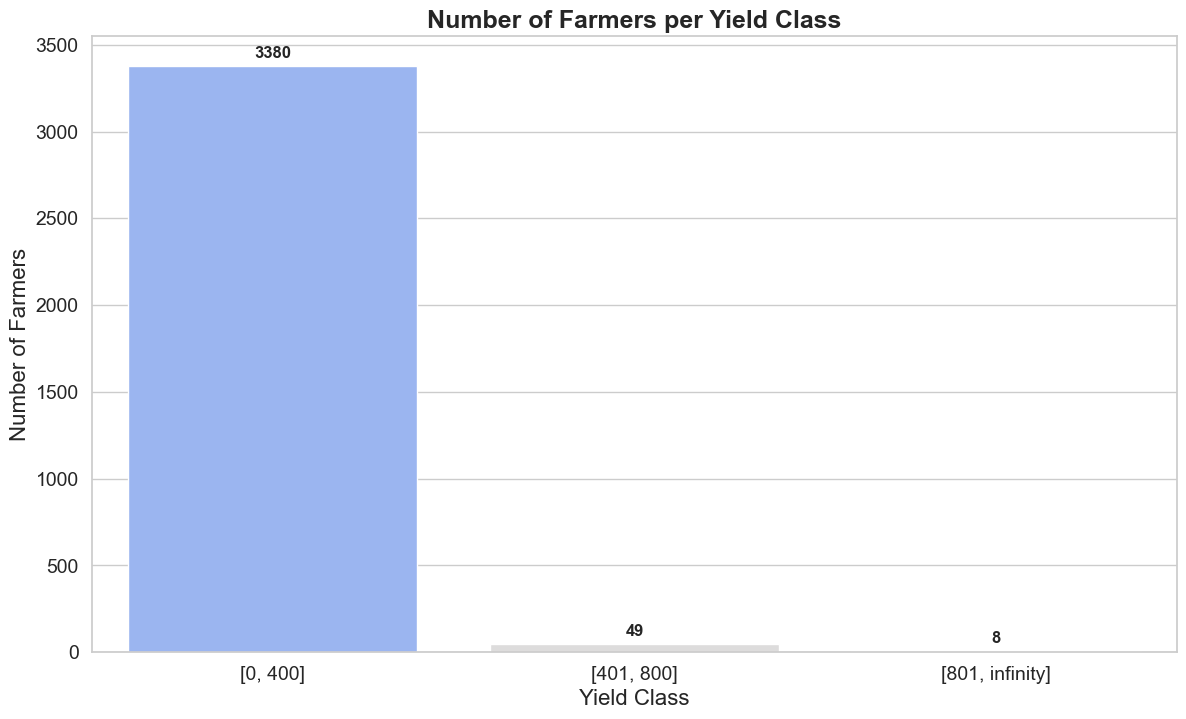

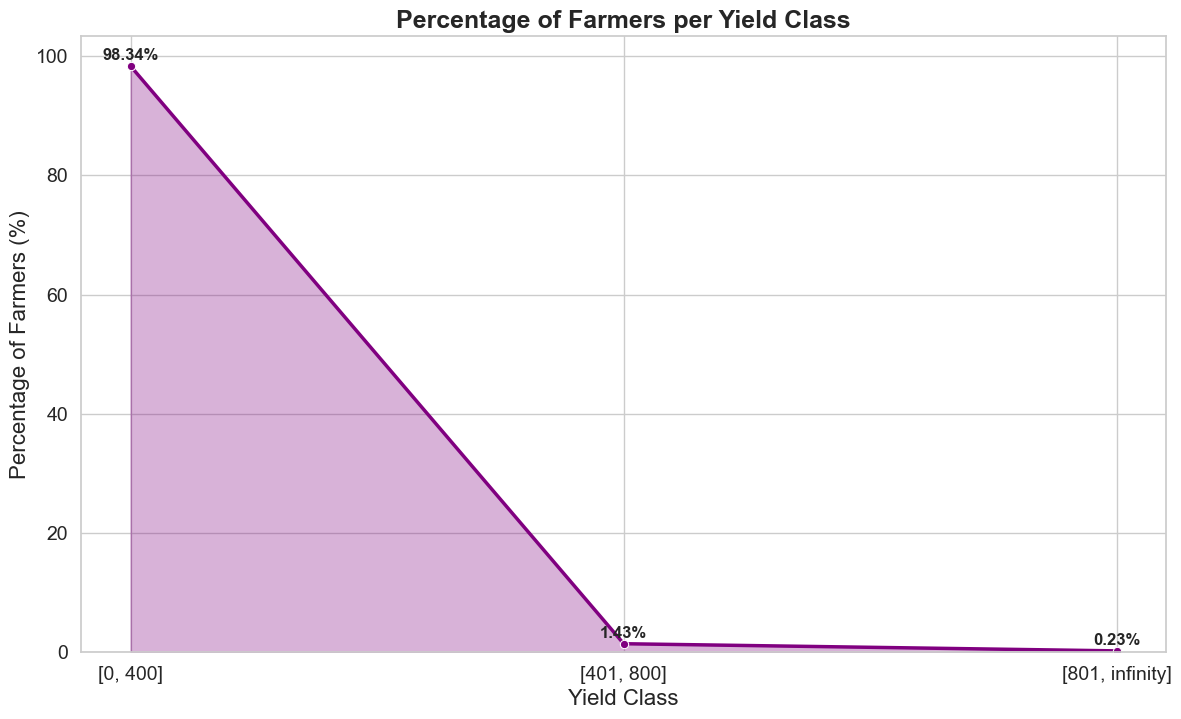

C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1258949608.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result, palette=colors)


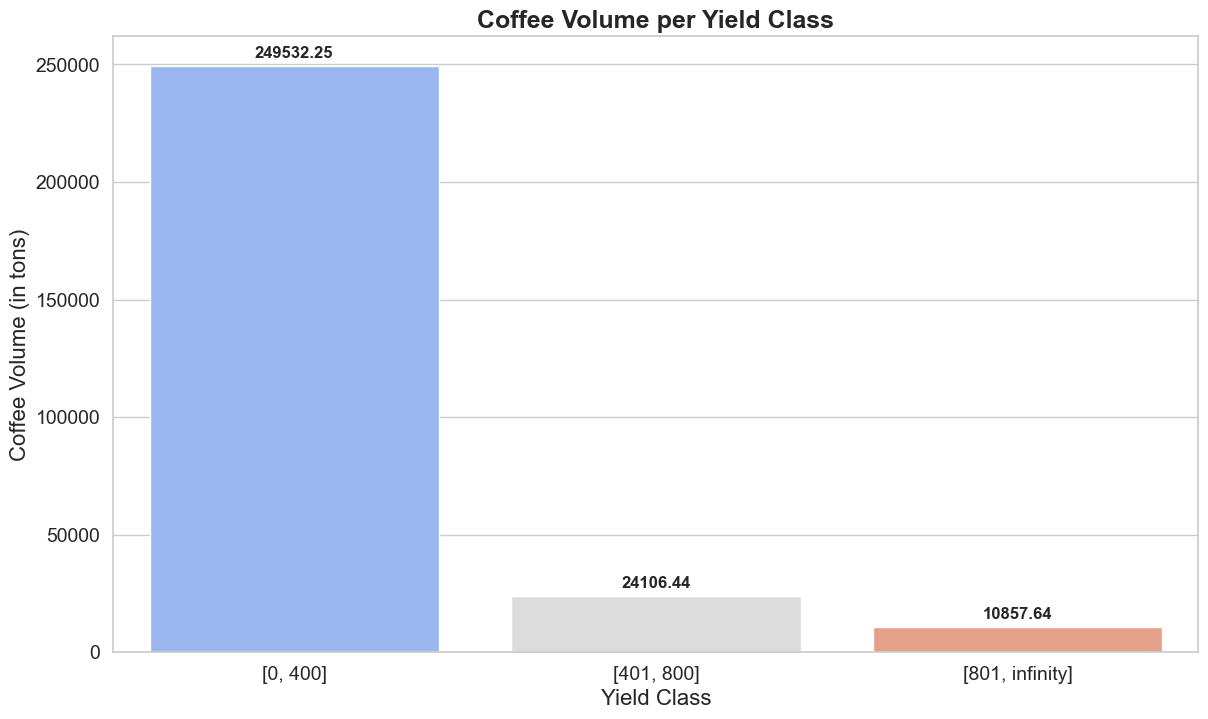

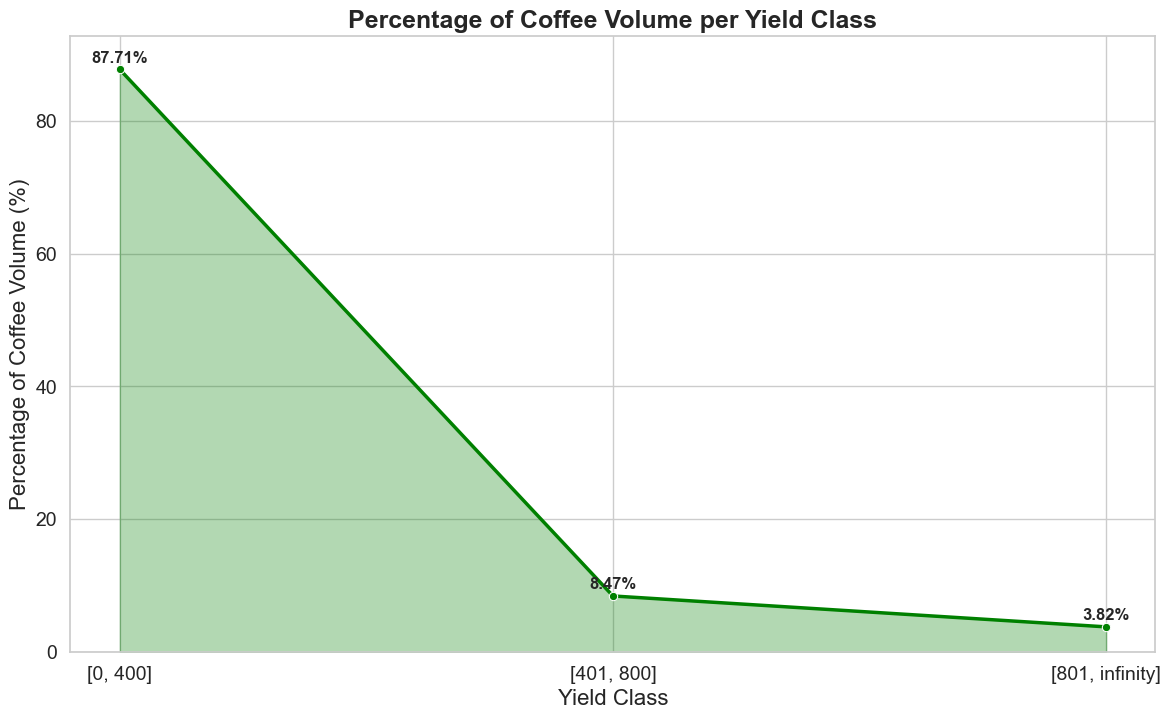

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check and convert percentages to numeric, if they are not already numeric
if result['Percentage_of_farmers'].dtype == 'object':
    result['Percentage_of_farmers'] = result['Percentage_of_farmers'].str.rstrip('%').astype(float)

if result['Percentage_of_volume'].dtype == 'object':
    result['Percentage_of_volume'] = result['Percentage_of_volume'].str.rstrip('%').astype(float)

# Ensure Coffee_Volume is numeric for plotting
result['Coffee_Volume'] = result['Coffee_Volume'].astype(float)

# Seting a style for the plots
sns.set(style="whitegrid")

# Colors for the plots
colors = sns.color_palette("coolwarm", len(result['Yield_Class']))

# Plotting Number of Farmers per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result, palette=colors)
plt.title('Number of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Number of Farmers', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Farmers per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_farmers', data=result, marker='o', color='purple', linewidth=2.5)
plt.fill_between(result['Yield_Class'], result['Percentage_of_farmers'], color='purple', alpha=0.3)
plt.title('Percentage of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Farmers (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result['Percentage_of_farmers']) + 5)  

# Annotate the points
for i, (x, y) in enumerate(zip(result['Yield_Class'], result['Percentage_of_farmers'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()

# Plotting Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result, palette=colors)
plt.title('Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Coffee Volume (in tons)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_volume', data=result, marker='o', color='green', linewidth=2.5)
plt.fill_between(result['Yield_Class'], result['Percentage_of_volume'], color='green', alpha=0.3)
plt.title('Percentage of Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Coffee Volume (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result['Percentage_of_volume']) + 5)  

# Annotate the points
for i, (x, y) in enumerate(zip(result['Yield_Class'], result['Percentage_of_volume'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()


### COOPERATIVE TWO

In [40]:
coop2 = pd.read_excel(r"C:\Users\OneHeart\Desktop\Study case\REGISTRE PRODUCTEUR_COOP2.xlsx")

In [41]:
# Removing duplicates in coorperative 2 data based on the 'Farmer Code' column
clean_coop2 = coop2.drop_duplicates(subset='Farmer Code')

# Displaying the number of rows before and after removing duplicates
print(f"Number of rows before removing duplicates: {len(coop2)}")
print(f"Number of rows after removing duplicates: {len(clean_coop2)}")

Number of rows before removing duplicates: 878
Number of rows after removing duplicates: 878


In [42]:
# Merging coorperative 2 with mapping and traceability data
full_data_2 = clean_coop2.merge(clean_trace_data, on='Farmer Code', how='left')
final_full_data_2 = full_data_2.merge(clean_mapping_data, on='Farmer Code', how='left')

In [43]:
final_full_data_2.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,REGION DE NAISSANCE,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,declarative superficy (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001,ZONGO,SENY,NaN,NaN,Homme,NaN,1.78046,...,MALE,85,10/2022,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001-P1,SENY,ZONGO,2023/05/04,1.78
1,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002,KOUDOUGOU,WAHOBO,NaN,NaN,Homme,NaN,2.63373,...,MALE,45,10/2022,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002-P1,WAHOBO,KOUDOUGOU,2023/05/04,2.63
2,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003,BONKOUNGO,OUMAR,NaN,NaN,Homme,NaN,2.15248,...,MALE,45,10/2022,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003-P1,OUMAR,BONKOUNGO,2023/05/04,2.15


In [44]:
final_full_data_2.count()

COOPERATIVE_x                                      878
VILLAGE                                            878
Farmer Code                                        878
NOM DU PRODUCTEUR                                  878
PRENOMS DU PRODUCTEUR                              878
REGION DE NAISSANCE                                  0
VILLAGE DE NAISSANCE                                 0
SEXE                                               878
ANNEE DE CREATION                                    0
declarative superficy (Declaration)                878
UNITE DE LA SUPERFICIE CERTIFIEE (Declaration)     878
SUPERFICIE DE LA PLANTATION CERTIFIEE (Mapping)      0
UNITE DE LA SUPERFICIE CERTIFIEE (Mapping)           0
UNITE DE VOLUME                                    878
Farmer Group Code                                  878
FULL NAME                                          878
Farmer gender                                      878
COH delivered volume in KG                         878
Delivery d

In [45]:

# ensiring that data is  betwin  september 2022 and noverber 2023 date range
final_full_data_2['Delivery date \n(Month/Year)'] = pd.to_datetime(final_full_data_2['Delivery date \n(Month/Year)'], format='%m/%Y', errors='coerce')

# Defining the date range
start_date = pd.to_datetime('2022-09-01')  # Start of September 2022
end_date = pd.to_datetime('2023-10-31')    # End of October 2023

# Selecting rows that fall within the date range
filtered_rowss_2 = final_full_data_2[
    (final_full_data_2['Delivery date \n(Month/Year)'] >= start_date) & 
    (final_full_data_2['Delivery date \n(Month/Year)'] <= end_date)
]

# Display the filtered rows
filtered_rowss_2.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,REGION DE NAISSANCE,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,declarative superficy (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001,ZONGO,SENY,NaN,NaN,Homme,NaN,1.78046,...,MALE,85,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001-P1,SENY,ZONGO,2023/05/04,1.78
1,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002,KOUDOUGOU,WAHOBO,NaN,NaN,Homme,NaN,2.63373,...,MALE,45,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002-P1,WAHOBO,KOUDOUGOU,2023/05/04,2.63
2,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003,BONKOUNGO,OUMAR,NaN,NaN,Homme,NaN,2.15248,...,MALE,45,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003-P1,OUMAR,BONKOUNGO,2023/05/04,2.15


In [46]:


# Fill NaN values in 'mapped_superficy' with values from 'declarative superficy (Declaration))'
filtered_rowss_2['Surface_Area_for_Yield'] = filtered_rowss_2['mapped_superficy'].fillna(filtered_rowss_2['declarative superficy (Declaration)'])

#  calculating the yield
filtered_rowss_2['Yield'] = filtered_rowss_2['COH delivered volume in KG'] / filtered_rowss_2['Surface_Area_for_Yield']

# Displaying the updated DataFrame
filtered_rowss_2.head(3)


,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,REGION DE NAISSANCE,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,declarative superficy (Declaration),...,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield
0,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001,ZONGO,SENY,NaN,NaN,Homme,NaN,1.78046,...,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001-P1,SENY,ZONGO,2023/05/04,1.78,1.78,47.752809
1,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002,KOUDOUGOU,WAHOBO,NaN,NaN,Homme,NaN,2.63373,...,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002-P1,WAHOBO,KOUDOUGOU,2023/05/04,2.63,2.63,17.110266
2,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003,BONKOUNGO,OUMAR,NaN,NaN,Homme,NaN,2.15248,...,2022-10-01,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003-P1,OUMAR,BONKOUNGO,2023/05/04,2.15,2.15,20.930233


In [47]:

#Defining thresholds 
thresholds = [0, 400, 801, float('inf')]  
labels = ['[0, 400]', '[401, 800]', '[801, infinity]']

# Classifying yield based on the new thresholds
filtered_rowss_2['Yield_Class'] = pd.cut(filtered_rowss_2['Yield'], bins=thresholds, labels=labels, right=False)

# Aggregating data by yield class
result_2 = filtered_rowss_2.groupby('Yield_Class').agg(
    Number_of_farmers=('Farmer Code', 'count'),
    Coffee_Volume=('Yield', 'sum')
).reset_index()




C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\2719005331.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_2 = filtered_rowss_2.groupby('Yield_Class').agg(


In [48]:
filtered_rowss_2.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,REGION DE NAISSANCE,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,declarative superficy (Declaration),...,COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield,Yield_Class
0,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001,ZONGO,SENY,NaN,NaN,Homme,NaN,1.78046,...,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0001-P1,SENY,ZONGO,2023/05/04,1.78,1.78,47.752809,"[0, 400]"
1,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002,KOUDOUGOU,WAHOBO,NaN,NaN,Homme,NaN,2.63373,...,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0002-P1,WAHOBO,KOUDOUGOU,2023/05/04,2.63,2.63,17.110266,"[0, 400]"
2,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003,BONKOUNGO,OUMAR,NaN,NaN,Homme,NaN,2.15248,...,COOP2,ALLAKOFFIKRO,CIV-SAN-SC111269-001-0003-P1,OUMAR,BONKOUNGO,2023/05/04,2.15,2.15,20.930233,"[0, 400]"


In [49]:
#calculating volume and percentages 

# Ensure that the relevant columns are numeric
filtered_rowss_2['Yield'] = pd.to_numeric(filtered_rowss_2['Yield'], errors='coerce')
result_2['Number_of_farmers'] = pd.to_numeric(result_2['Number_of_farmers'], errors='coerce')
result_2['Coffee_Volume'] = pd.to_numeric(result_2['Coffee_Volume'], errors='coerce')

# Calculate total volume and total farmers
total_volume = filtered_rowss_2['Yield'].sum()
total_farmers = filtered_rowss_2['Farmer Code'].nunique()

# Calculate percentages
result_2['Percentage_of_farmers'] = (result_2['Number_of_farmers'] / total_farmers) * 100
result_2['Percentage_of_volume'] = (result_2['Coffee_Volume'] / total_volume) * 100

# Format percentages to 2 decimal places and add a percentage sign
result_2['Percentage_of_farmers'] = result_2['Percentage_of_farmers'].apply(lambda x: f"{x:.2f}%")
result_2['Percentage_of_volume'] = result_2['Percentage_of_volume'].apply(lambda x: f"{x:.2f}%")

# Format Coffee_Volume to 2 decimal places
result_2['Coffee_Volume'] = result_2['Coffee_Volume'].apply(lambda x: f"{x:.2f}")



In [50]:
result_2.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",878,15234.06,100.00%,100.00%
1,"[401, 800]",0,0.00,0.00%,0.00%
2,"[801, infinity]",0,0.00,0.00%,0.00%


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1668378380.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result_2, palette=colors)


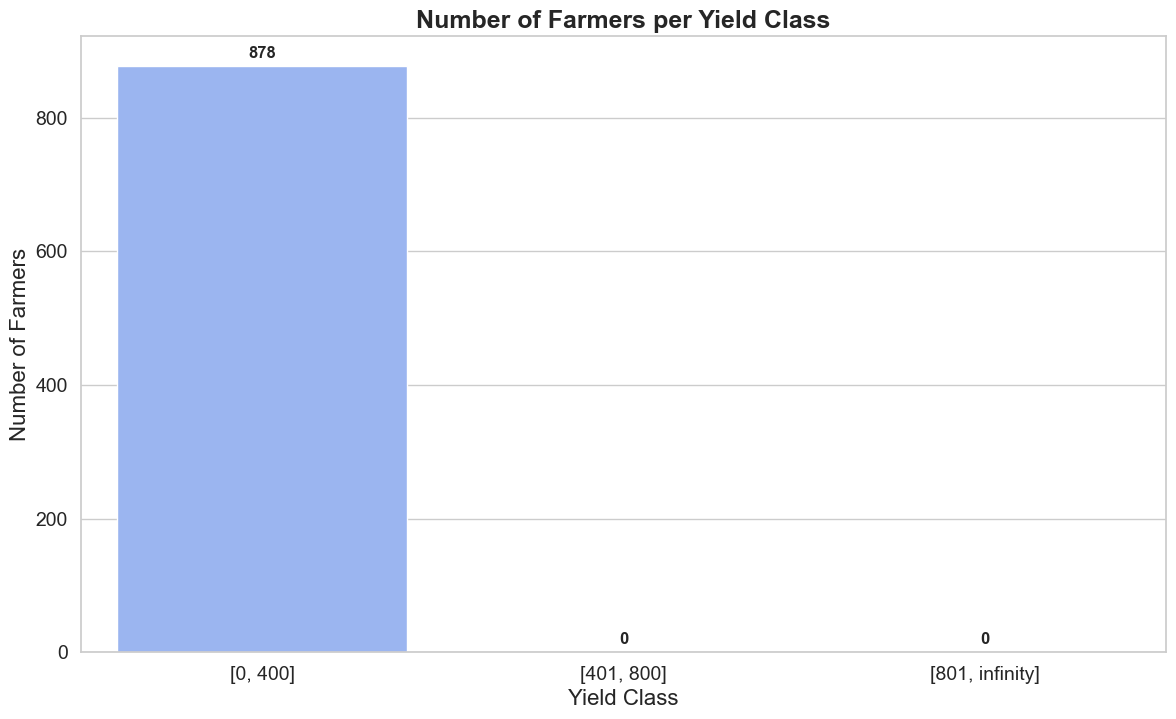

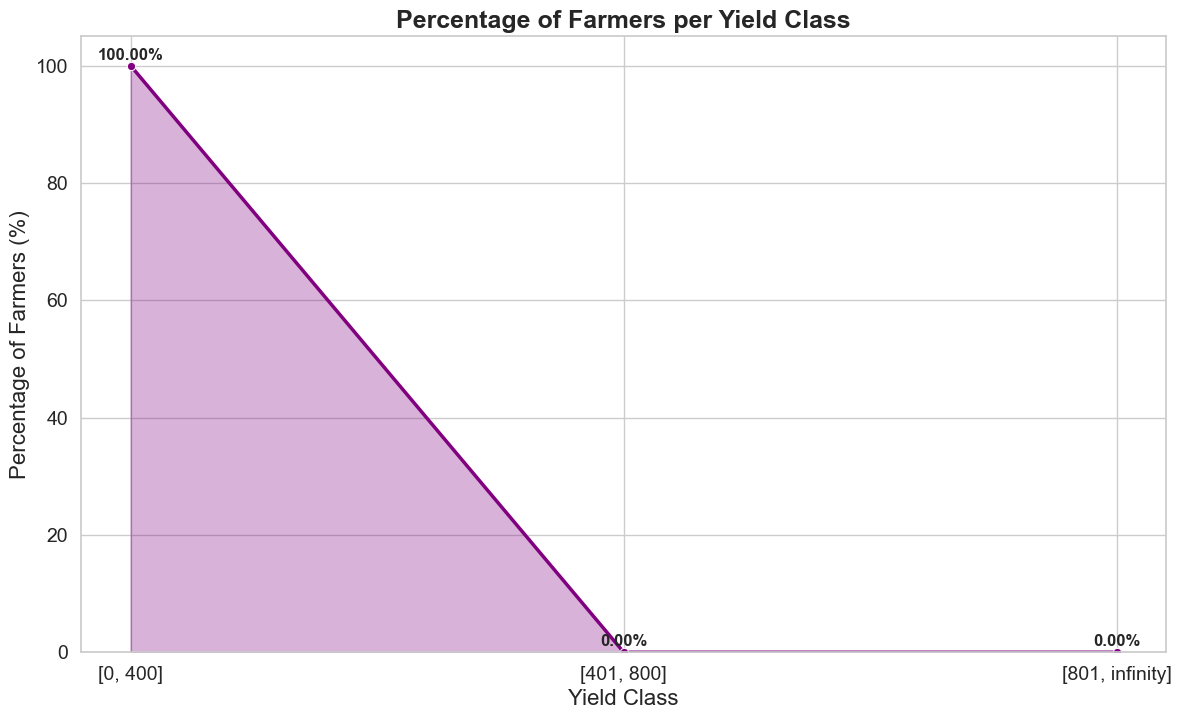

C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1668378380.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result_2, palette=colors)


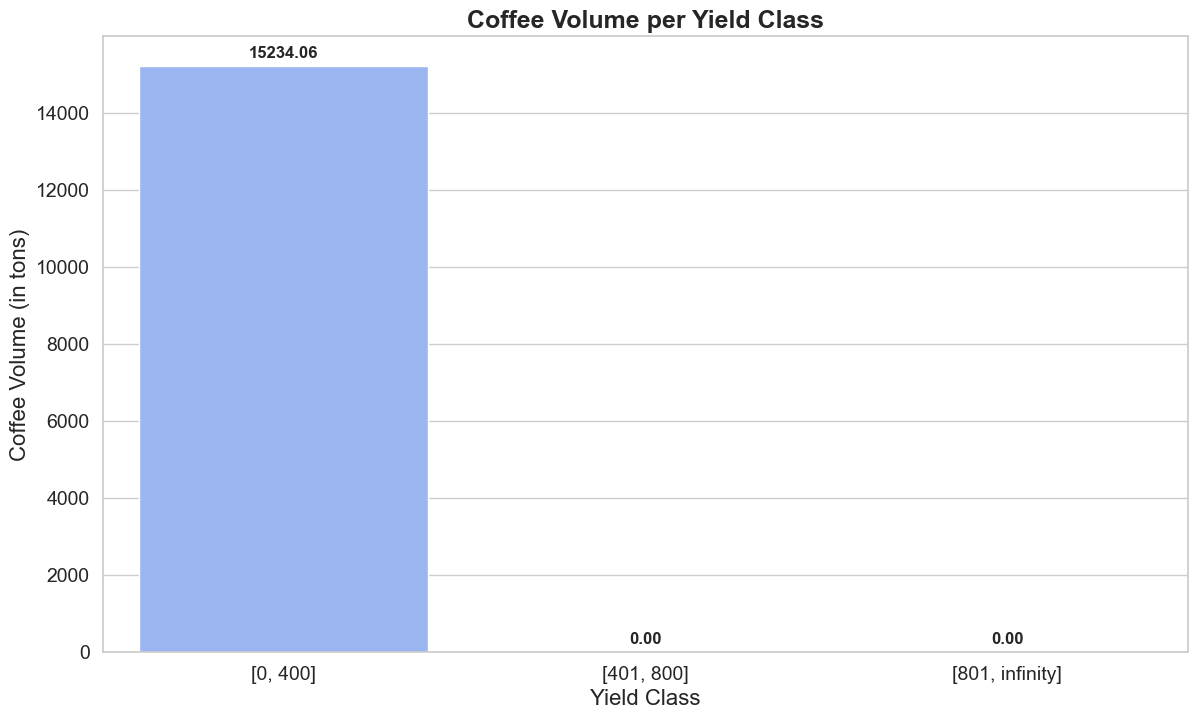

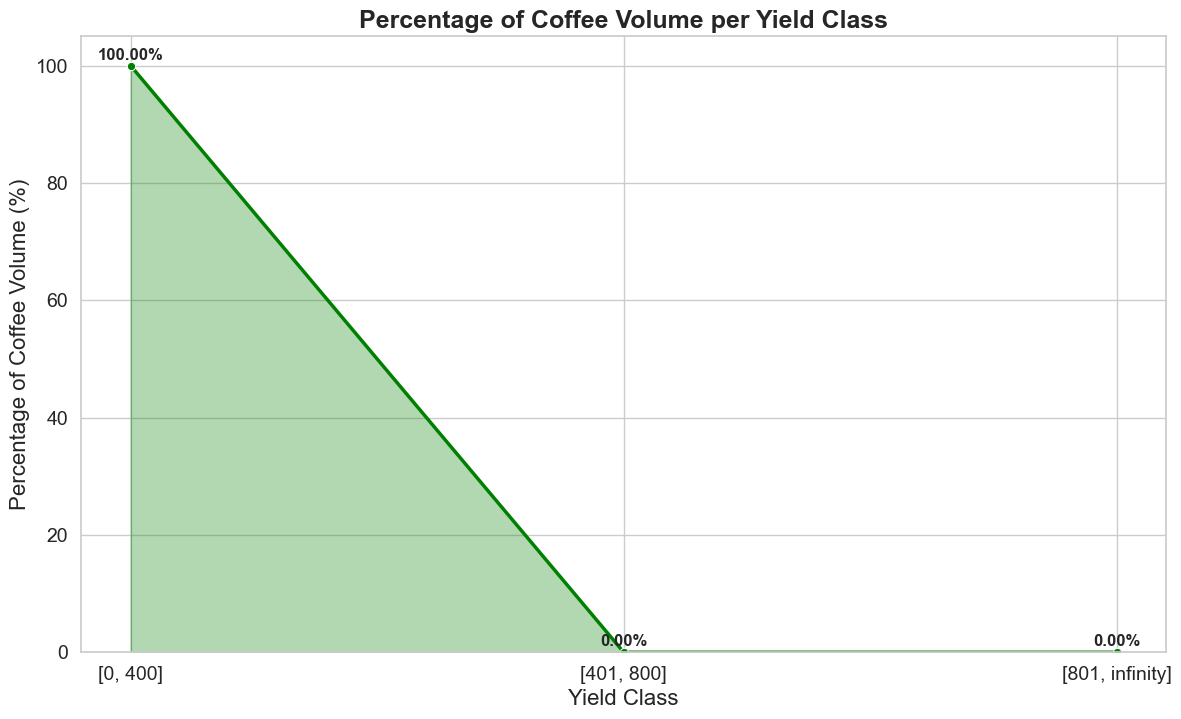

In [51]:
## graphical plotting 

# Ensure percentages are numeric without the '%' sign for plotting
if result_2['Percentage_of_farmers'].dtype == 'object':
    result_2['Percentage_of_farmers'] = result_2['Percentage_of_farmers'].str.rstrip('%').astype(float)

if result_2['Percentage_of_volume'].dtype == 'object':
    result_2['Percentage_of_volume'] = result_2['Percentage_of_volume'].str.rstrip('%').astype(float)

# Ensure Coffee_Volume is numeric for plotting
result_2['Coffee_Volume'] = result_2['Coffee_Volume'].astype(float)

# Set a beautiful style for the plots
sns.set(style="whitegrid")

# Colors for the plots
colors = sns.color_palette("coolwarm", len(result_2['Yield_Class']))

# Plotting Number of Farmers per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result_2, palette=colors)
plt.title('Number of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Number of Farmers', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Farmers per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_farmers', data=result_2, marker='o', color='purple', linewidth=2.5)
plt.fill_between(result_2['Yield_Class'], result_2['Percentage_of_farmers'], color='purple', alpha=0.3)
plt.title('Percentage of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Farmers (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result_2['Percentage_of_farmers']) + 5)  

# Annotate the points
for i, (x, y) in enumerate(zip(result_2['Yield_Class'], result_2['Percentage_of_farmers'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()

# Plotting Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result_2, palette=colors)
plt.title('Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Coffee Volume (in tons)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_volume', data=result_2, marker='o', color='green', linewidth=2.5)
plt.fill_between(result_2['Yield_Class'], result_2['Percentage_of_volume'], color='green', alpha=0.3)
plt.title('Percentage of Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Coffee Volume (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result_2['Percentage_of_volume']) + 5)  

# Annotate the points
for i, (x, y) in enumerate(zip(result_2['Yield_Class'], result_2['Percentage_of_volume'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()


### COOPERATIVE THREE

In [52]:
coop3 = pd.read_excel(r"C:\Users\OneHeart\Desktop\Study case\REGISTRE PRODUCTEUR_COOP3.xlsx")

In [53]:
# Remove duplicates in coorperative 3 data based on the 'Farmer Code' column
clean_coop3 = coop3.drop_duplicates(subset='Farmer Code')

# Display the number of rows before and after removing duplicates
print(f"Number of rows before removing duplicates: {len(coop3)}")
print(f"Number of rows after removing duplicates: {len(clean_coop3)}")

Number of rows before removing duplicates: 1339
Number of rows after removing duplicates: 1339


In [54]:
# Merge coorperative 3 data with mapping and traceability data
full_data_3 = clean_coop3.merge(clean_trace_data, on='Farmer Code', how='left')
final_full_data_3 = full_data_3.merge(clean_mapping_data, on='Farmer Code', how='left')

In [55]:
final_full_data_3.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,PRODUIT,declarative superficy (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170,AMON,HORTANCE KOCOTTI,NaN,Femme,NaN,NaN,2.0,...,FEMALE,305.0,10/2022,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170-P1,HORTANCE KOCOTTI,AMON,2022/12/27,1.44
1,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171,GEORGES,ASSAMOI,NaN,Homme,NaN,NaN,5.0,...,MALE,1585.0,10/2022,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171-P1,ASSAMOI,GEORGES,2022/12/27,2.34
2,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172,N'GORAN,AMA MARIE,NaN,Femme,NaN,NaN,3.0,...,FEMALE,1420.0,10/2022,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172-P1,AMA MARIE,N'GORAN,2022/12/27,2.58


In [56]:
# ensiring that data is  betwin  september 2022 and noverber 2023 date range
# Convert the 'Delivery date \n(Month/Year)' column to datetime format
final_full_data_3['Delivery date \n(Month/Year)'] = pd.to_datetime(final_full_data_3['Delivery date \n(Month/Year)'], format='%m/%Y', errors='coerce')

# Defining the date range
start_date = pd.to_datetime('2022-09-01')  # Start of September 2022
end_date = pd.to_datetime('2023-10-31')    # End of October 2023

# Selecting rows that fall within the date range
filtered_rowss_3 = final_full_data_3[
    (final_full_data_3['Delivery date \n(Month/Year)'] >= start_date) & 
    (final_full_data_3['Delivery date \n(Month/Year)'] <= end_date)
]

# Display the filtered rows
filtered_rowss_3.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,PRODUIT,declarative superficy (Declaration),...,Farmer gender,COH delivered volume in KG,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy
0,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170,AMON,HORTANCE KOCOTTI,NaN,Femme,NaN,NaN,2.0,...,FEMALE,305.0,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170-P1,HORTANCE KOCOTTI,AMON,2022/12/27,1.44
1,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171,GEORGES,ASSAMOI,NaN,Homme,NaN,NaN,5.0,...,MALE,1585.0,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171-P1,ASSAMOI,GEORGES,2022/12/27,2.34
2,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172,N'GORAN,AMA MARIE,NaN,Femme,NaN,NaN,3.0,...,FEMALE,1420.0,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172-P1,AMA MARIE,N'GORAN,2022/12/27,2.58


In [57]:


# Fill NaN values in 'mapped_superficy' with values from 'declarative superficy (Declaration))'
filtered_rowss_3['Surface_Area_for_Yield'] = filtered_rowss_3['mapped_superficy'].fillna(filtered_rowss_3['declarative superficy (Declaration)'])

# calculating the yield
filtered_rowss_3['Yield'] = filtered_rowss_3['COH delivered volume in KG'] / filtered_rowss_3['Surface_Area_for_Yield']

# Display the updated DataFrame
filtered_rowss_3.head(3)


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1019188824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss_3['Surface_Area_for_Yield'] = filtered_rowss_3['mapped_superficy'].fillna(filtered_rowss_3['declarative superficy (Declaration)'])
C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1019188824.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss_3['Yield'] = filtered_rowss_3['COH delivered volume in KG'] / filtered_rowss_3['Surface_Area_for_Yield']


,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,PRODUIT,declarative superficy (Declaration),...,Delivery date \n(Month/Year),COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield
0,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170,AMON,HORTANCE KOCOTTI,NaN,Femme,NaN,NaN,2.0,...,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170-P1,HORTANCE KOCOTTI,AMON,2022/12/27,1.44,1.44,211.805556
1,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171,GEORGES,ASSAMOI,NaN,Homme,NaN,NaN,5.0,...,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171-P1,ASSAMOI,GEORGES,2022/12/27,2.34,2.34,677.350427
2,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172,N'GORAN,AMA MARIE,NaN,Femme,NaN,NaN,3.0,...,2022-10-01,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172-P1,AMA MARIE,N'GORAN,2022/12/27,2.58,2.58,550.387597


In [58]:


# Define the updated thresholds and labels
thresholds = [0, 400, 801, float('inf')]  # Adjusted thresholds: 0 to 400, 401 to 800, 801 and above
labels = ['[0, 400]', '[401, 800]', '[801, infinity]']

# Classifying yield based on the new thresholds
filtered_rowss_3['Yield_Class'] = pd.cut(filtered_rowss_3['Yield'], bins=thresholds, labels=labels, right=False)

# Aggregating data by yield class
result_3 = filtered_rowss_3.groupby('Yield_Class').agg(
    Number_of_farmers=('Farmer Code', 'count'),
    Coffee_Volume=('Yield', 'sum')
).reset_index()


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\978089492.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss_3['Yield_Class'] = pd.cut(filtered_rowss_3['Yield'], bins=thresholds, labels=labels, right=False)
C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\978089492.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_3 = filtered_rowss_3.groupby('Yield_Class').agg(


In [59]:
filtered_rowss_3.head(3)

,COOPERATIVE_x,VILLAGE,Farmer Code,NOM DU PRODUCTEUR,PRENOMS DU PRODUCTEUR,VILLAGE DE NAISSANCE,SEXE,ANNEE DE CREATION,PRODUIT,declarative superficy (Declaration),...,COOPERATIVE_y,locality,Farm Code,Firstname,Surna,dt_last_up,mapped_superficy,Surface_Area_for_Yield,Yield,Yield_Class
0,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170,AMON,HORTANCE KOCOTTI,NaN,Femme,NaN,NaN,2.0,...,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0170-P1,HORTANCE KOCOTTI,AMON,2022/12/27,1.44,1.44,211.805556,"[0, 400]"
1,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171,GEORGES,ASSAMOI,NaN,Homme,NaN,NaN,5.0,...,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0171-P1,ASSAMOI,GEORGES,2022/12/27,2.34,2.34,677.350427,"[401, 800]"
2,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172,N'GORAN,AMA MARIE,NaN,Femme,NaN,NaN,3.0,...,COOP3,ADOUKRO,CIV-AGN-SC040047-001-0172-P1,AMA MARIE,N'GORAN,2022/12/27,2.58,2.58,550.387597,"[401, 800]"


In [60]:

#claculating volume and percentages 
# Ensuring that the relevant columns are numeric
filtered_rowss_3['Yield'] = pd.to_numeric(filtered_rowss_3['Yield'], errors='coerce')
result_3['Number_of_farmers'] = pd.to_numeric(result_3['Number_of_farmers'], errors='coerce')
result_3['Coffee_Volume'] = pd.to_numeric(result_3['Coffee_Volume'], errors='coerce')

# Calculate total volume and total farmers
total_volume = filtered_rowss_3['Yield'].sum()
total_farmers = filtered_rowss_3['Farmer Code'].nunique()

# Calculate percentages
result_3['Percentage_of_farmers'] = (result_3['Number_of_farmers'] / total_farmers) * 100
result_3['Percentage_of_volume'] = (result_3['Coffee_Volume'] / total_volume) * 100

# Format percentages to 2 decimal places and add a percentage sign
result_3['Percentage_of_farmers'] = result_3['Percentage_of_farmers'].apply(lambda x: f"{x:.2f}%")
result_3['Percentage_of_volume'] = result_3['Percentage_of_volume'].apply(lambda x: f"{x:.2f}%")

# Format Coffee_Volume to 2 decimal places
result_3['Coffee_Volume'] = result_3['Coffee_Volume'].apply(lambda x: f"{x:.2f}")



C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1074186953.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rowss_3['Yield'] = pd.to_numeric(filtered_rowss_3['Yield'], errors='coerce')


In [61]:
result_3.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",602,100124.59,48.28%,16.49%
1,"[401, 800]",506,256647.29,40.58%,42.28%
2,"[801, infinity]",139,250290.38,11.15%,41.23%


C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1898122512.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result_3, palette=colors)


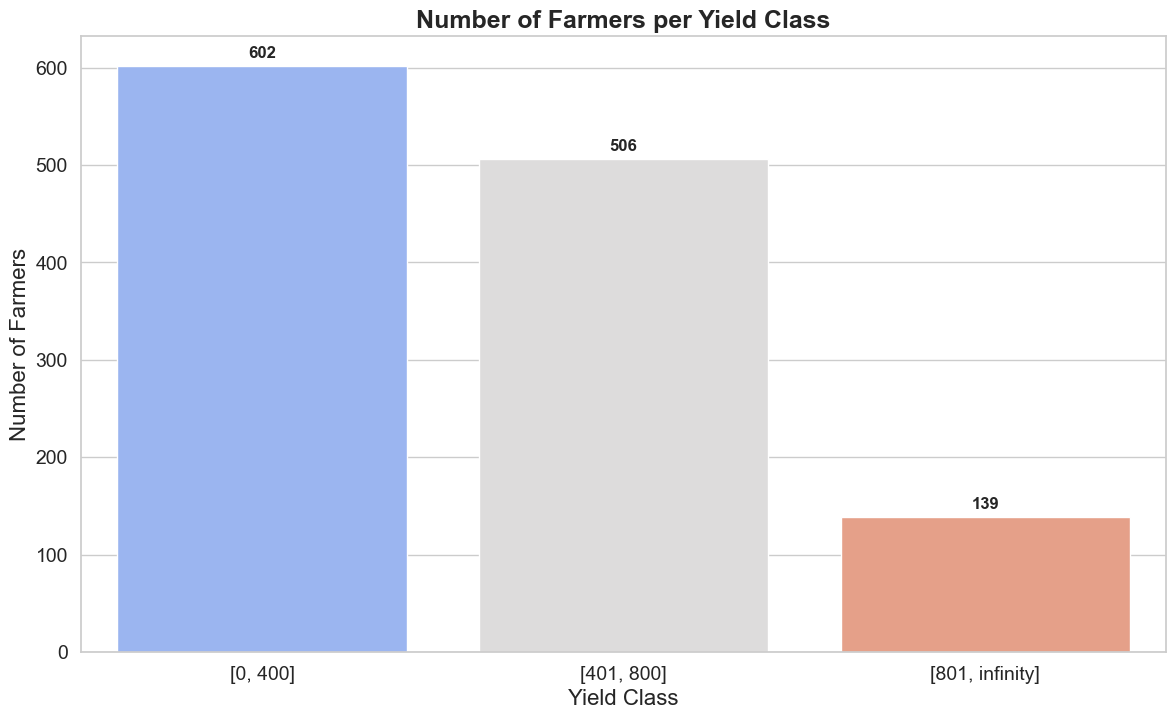

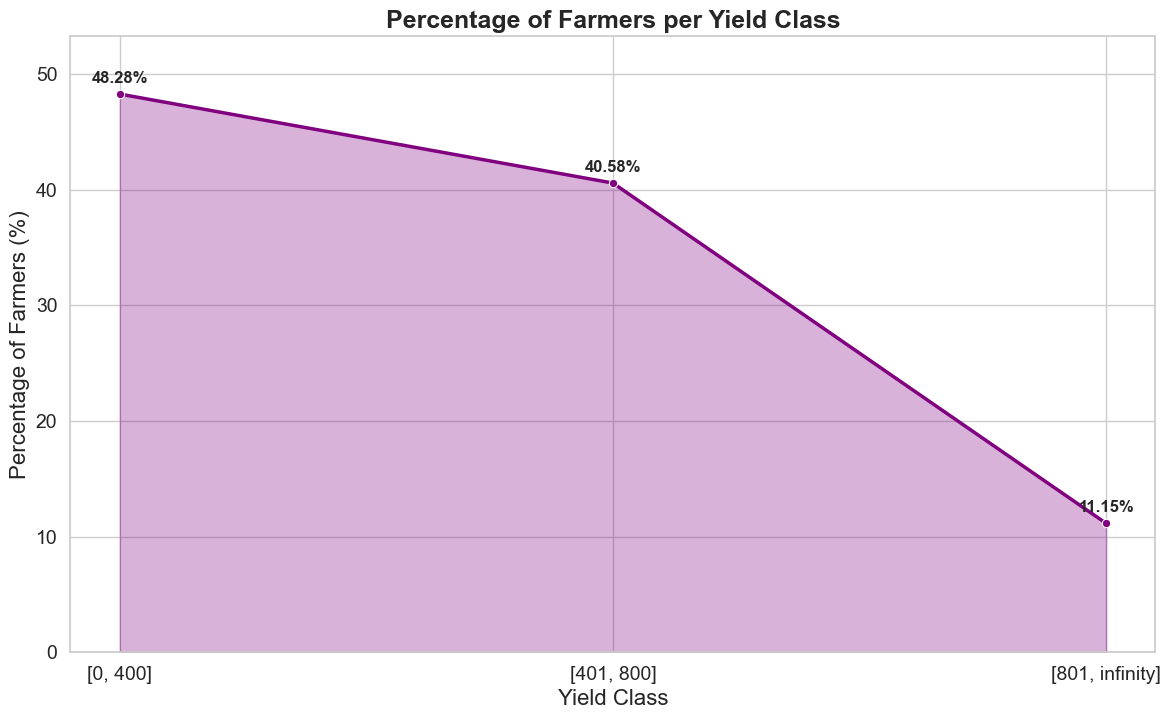

C:\Users\OneHeart\AppData\Local\Temp\ipykernel_10104\1898122512.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result_3, palette=colors)


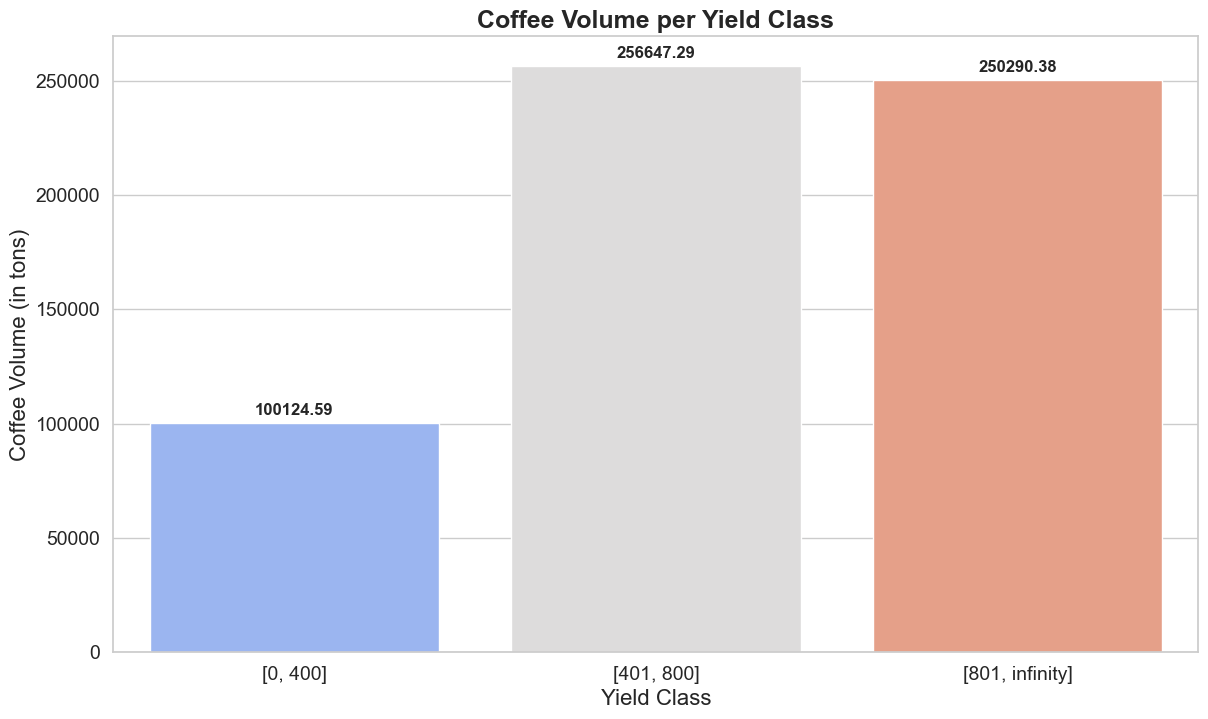

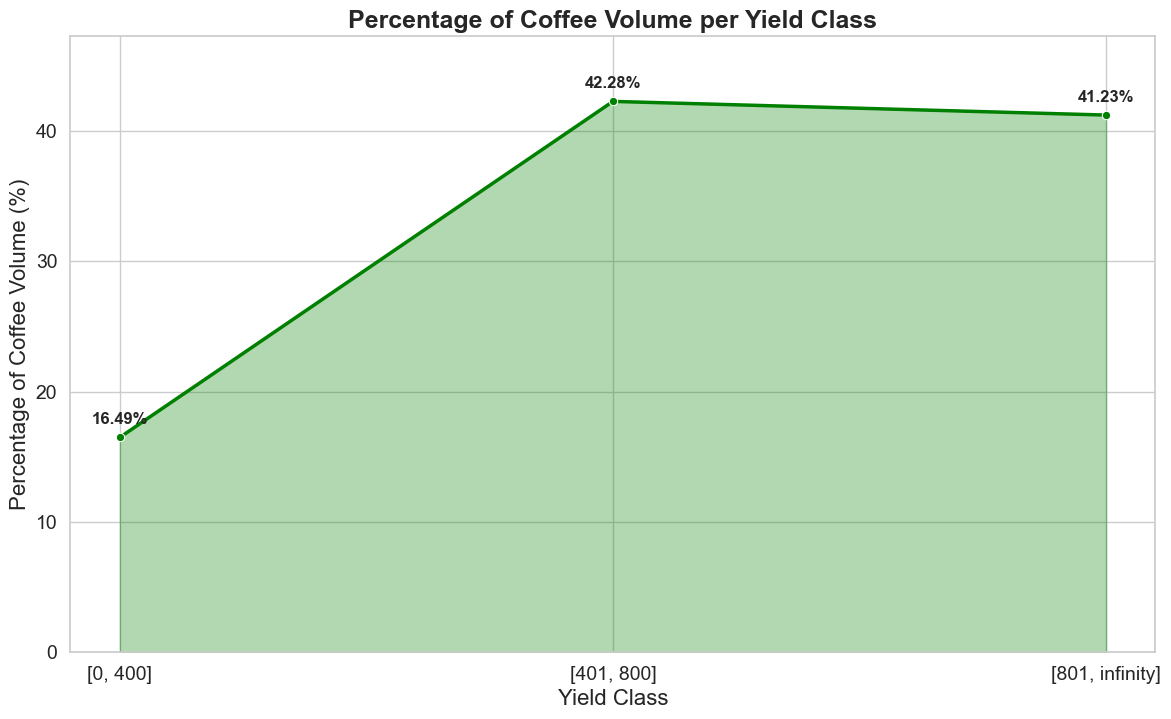

In [62]:
#Ploting 

# Ensure percentages are numeric without the '%' sign for plotting
if result_3['Percentage_of_farmers'].dtype == 'object':
    result_3['Percentage_of_farmers'] = result_3['Percentage_of_farmers'].str.rstrip('%').astype(float)

if result_3['Percentage_of_volume'].dtype == 'object':
    result_3['Percentage_of_volume'] = result_3['Percentage_of_volume'].str.rstrip('%').astype(float)

# Ensure Coffee_Volume is numeric for plotting
result_3['Coffee_Volume'] = result_3['Coffee_Volume'].astype(float)

# Set a beautiful style for the plots
sns.set(style="whitegrid")

# Colors for the plots
colors = sns.color_palette("coolwarm", len(result_3['Yield_Class']))

# Plotting Number of Farmers per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Number_of_farmers', data=result_3, palette=colors)
plt.title('Number of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Number of Farmers', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Farmers per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_farmers', data=result_3, marker='o', color='purple', linewidth=2.5)
plt.fill_between(result_3['Yield_Class'], result_3['Percentage_of_farmers'], color='purple', alpha=0.3)
plt.title('Percentage of Farmers per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Farmers (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result_3['Percentage_of_farmers']) + 5)

# Annotate the points
for i, (x, y) in enumerate(zip(result_3['Yield_Class'], result_3['Percentage_of_farmers'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()

# Plotting Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Yield_Class', y='Coffee_Volume', data=result_3, palette=colors)
plt.title('Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Coffee Volume (in tons)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate the bars
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, weight='bold')

plt.show()

# Plotting Percentage of Coffee Volume per Yield Class
plt.figure(figsize=(14, 8))
lineplot = sns.lineplot(x='Yield_Class', y='Percentage_of_volume', data=result_3, marker='o', color='green', linewidth=2.5)
plt.fill_between(result_3['Yield_Class'], result_3['Percentage_of_volume'], color='green', alpha=0.3)
plt.title('Percentage of Coffee Volume per Yield Class', fontsize=18, weight='bold')
plt.xlabel('Yield Class', fontsize=16)
plt.ylabel('Percentage of Coffee Volume (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, max(result_3['Percentage_of_volume']) + 5)  

# Annotate the points
for i, (x, y) in enumerate(zip(result_3['Yield_Class'], result_3['Percentage_of_volume'])):
    plt.text(i, y + 1, f'{y:.2f}%', ha='center', fontsize=12, weight='bold')

plt.show()


### ADDING ALL TOGETHER 

In [63]:
import pandas as pd

# Concatenate the DataFrames along the rows
combined_df = pd.concat([result, result_2, result_3], keys=['result', 'result_2', 'result_3'], names=['Source'])



In [64]:
result.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",3380,249532.25,98.34,87.71
1,"[401, 800]",49,24106.44,1.43,8.47
2,"[801, infinity]",8,10857.64,0.23,3.82


In [65]:
result_2.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",878,15234.06,100.0,100.0
1,"[401, 800]",0,0.00,0.0,0.0
2,"[801, infinity]",0,0.00,0.0,0.0


In [66]:
result_3.head()

,Yield_Class,Number_of_farmers,Coffee_Volume,Percentage_of_farmers,Percentage_of_volume
0,"[0, 400]",602,100124.59,48.28,16.49
1,"[401, 800]",506,256647.29,40.58,42.28
2,"[801, infinity]",139,250290.38,11.15,41.23


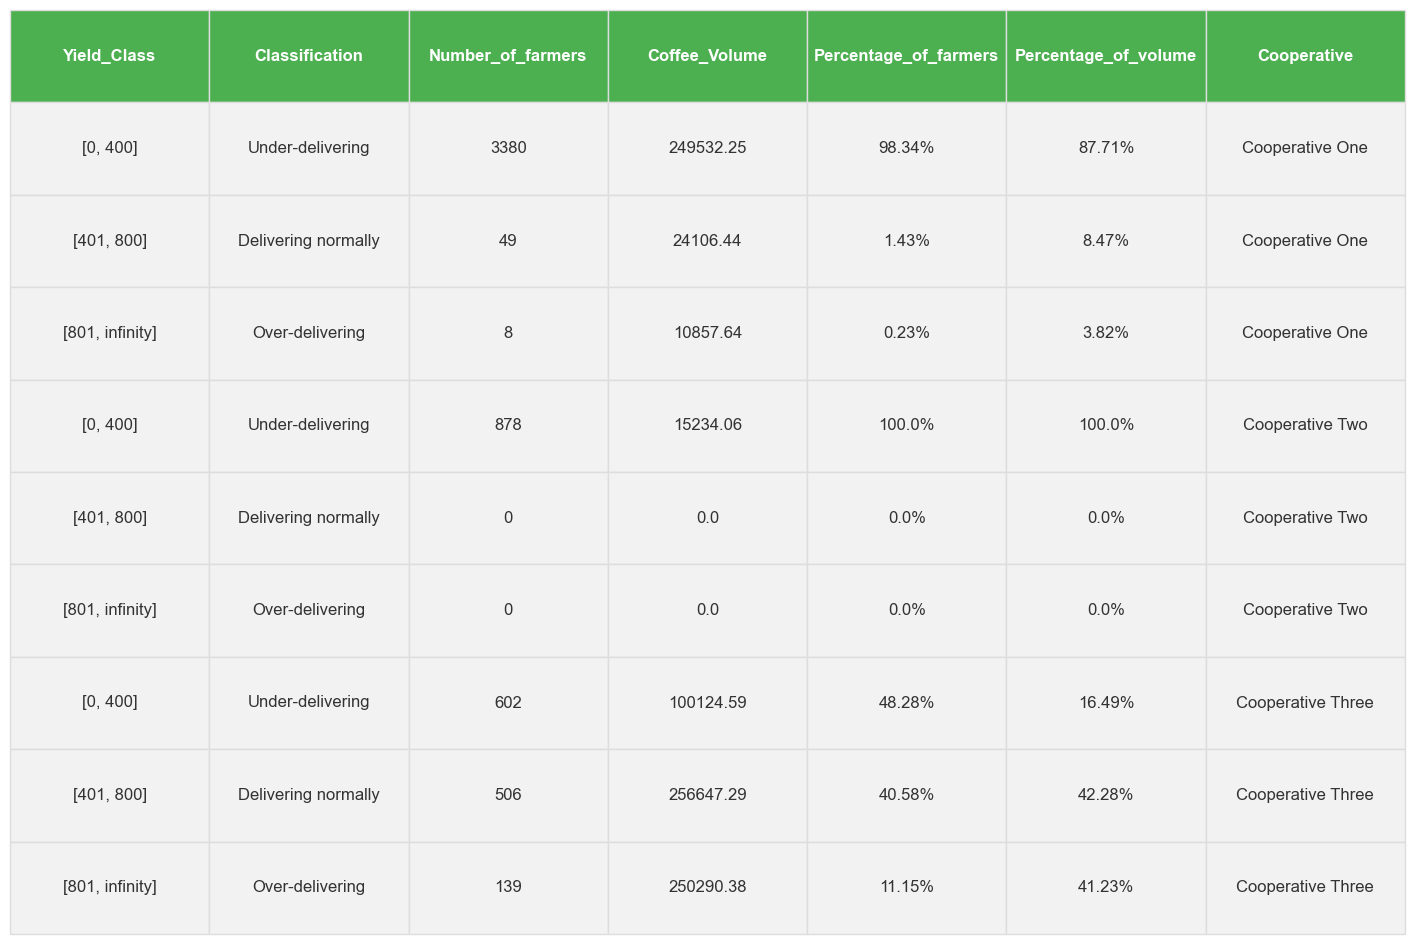

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for Cooperative One
data_coop_one = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Classification': ['Under-delivering', 'Delivering normally', 'Over-delivering'],
    'Number_of_farmers': [3380, 49, 8],
    'Coffee_Volume': [249532.25, 24106.44, 10857.64],
    'Percentage_of_farmers': ['98.34%', '1.43%', '0.23%'],
    'Percentage_of_volume': ['87.71%', '8.47%', '3.82%']
}
df_coop_one = pd.DataFrame(data_coop_one)
df_coop_one['Cooperative'] = 'Cooperative One'

# Data for Cooperative Two
data_coop_two = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Classification': ['Under-delivering', 'Delivering normally', 'Over-delivering'],
    'Number_of_farmers': [878, 0, 0],
    'Coffee_Volume': [15234.06, 0.00, 0.00],
    'Percentage_of_farmers': ['100.0%', '0.0%', '0.0%'],
    'Percentage_of_volume': ['100.0%', '0.0%', '0.0%']
}
df_coop_two = pd.DataFrame(data_coop_two)
df_coop_two['Cooperative'] = 'Cooperative Two'

# Data for Cooperative Three
data_coop_three = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Classification': ['Under-delivering', 'Delivering normally', 'Over-delivering'],
    'Number_of_farmers': [602, 506, 139],
    'Coffee_Volume': [100124.59, 256647.29, 250290.38],
    'Percentage_of_farmers': ['48.28%', '40.58%', '11.15%'],
    'Percentage_of_volume': ['16.49%', '42.28%', '41.23%']
}
df_coop_three = pd.DataFrame(data_coop_three)
df_coop_three['Cooperative'] = 'Cooperative Three'

# Combine all DataFrames into one
combined_result = pd.concat([df_coop_one, df_coop_two, df_coop_three], ignore_index=True)

# Define styling for the table
def style_table(ax, df):
    # Create a table and add it to the axes
    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])

    # Set font size and color for the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.2)  # Scale table size
    
    # Apply background color and text color
    for key, cell in table._cells.items():
        cell.set_edgecolor('#dddddd')
        if key[0] == 0:  # Header cells
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4CAF50')  # Dark green for header
        else:
            cell.set_facecolor('#f2f2f2')  # Light gray for body
            cell.set_text_props(color='#333333')  # Dark text color

    # Hide axes
    ax.axis('off')

# Create a plot
fig, ax = plt.subplots(figsize=(18, 12))  # Adjust size as needed
style_table(ax, combined_result)

# Show the plot
plt.show()


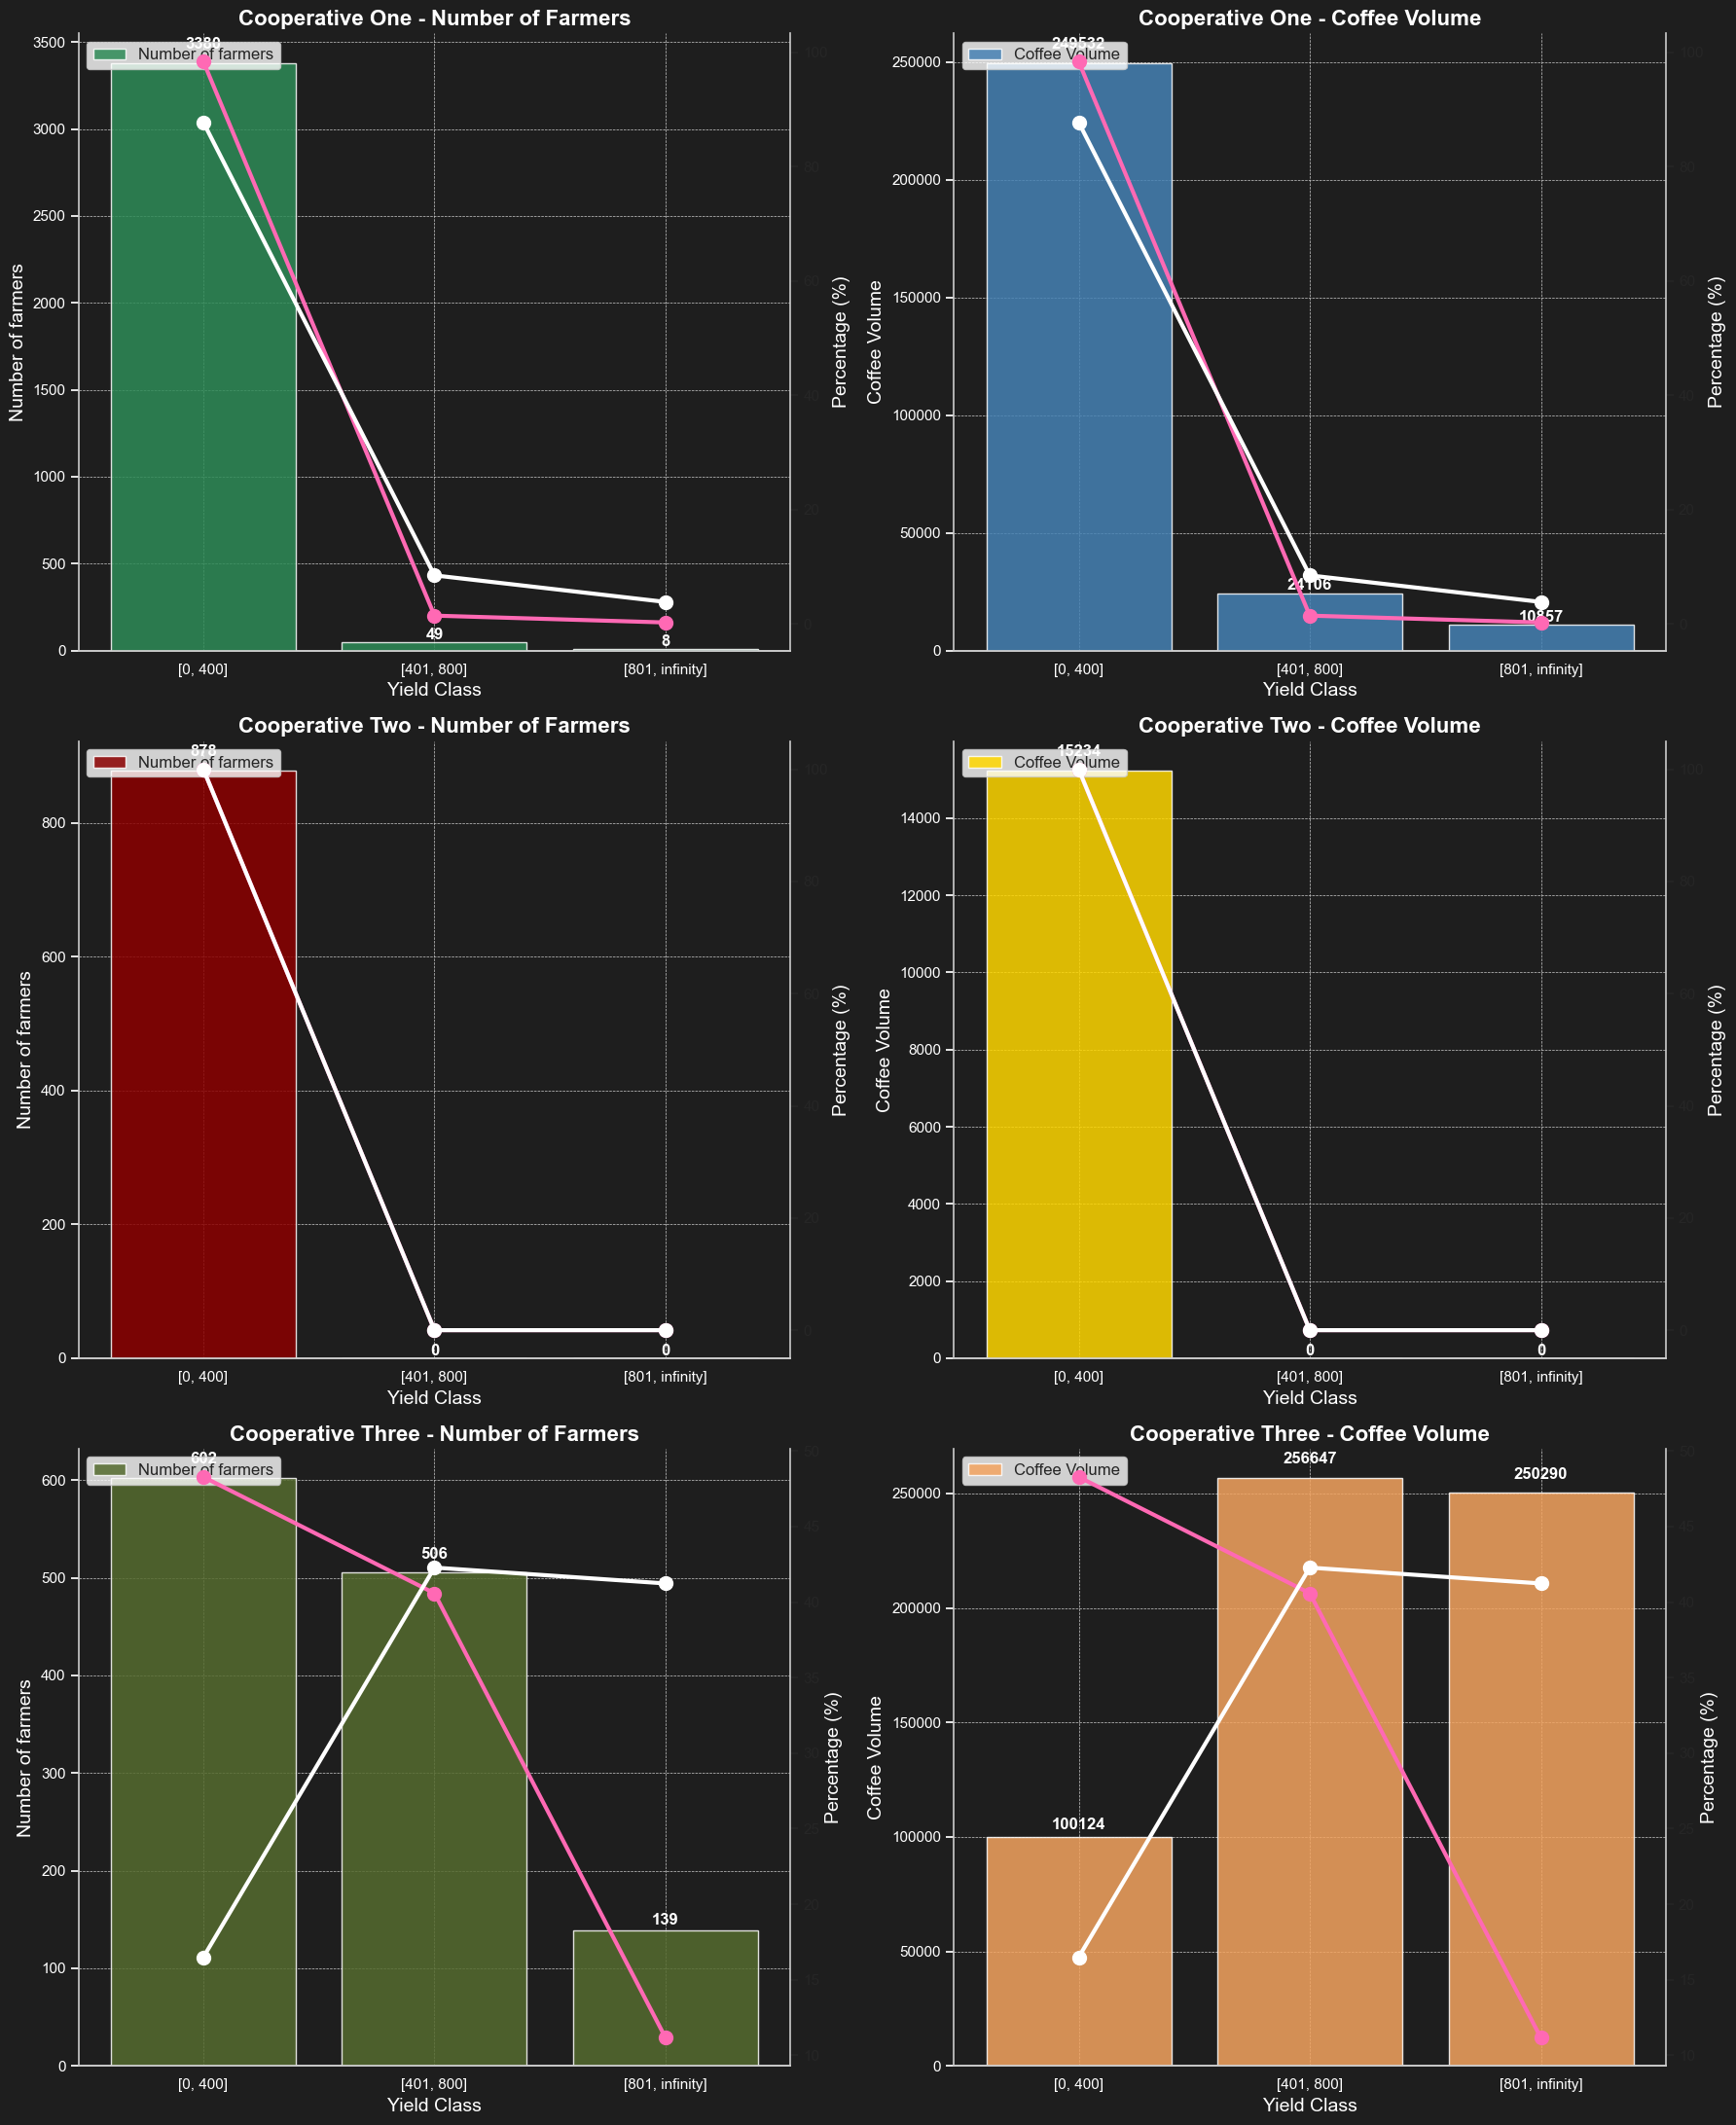

In [69]:


# Data for Cooperative One
data_coop_one = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Number_of_farmers': [3380, 49, 8],
    'Coffee_Volume': [249532.25, 24106.44, 10857.64],
    'Percentage_of_farmers': [98.34, 1.43, 0.23],
    'Percentage_of_volume': [87.71, 8.47, 3.82]
}
df_coop_one = pd.DataFrame(data_coop_one)
df_coop_one['Cooperative'] = 'Cooperative One'

# Data for Cooperative Two
data_coop_two = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Number_of_farmers': [878, 0, 0],
    'Coffee_Volume': [15234.06, 0.00, 0.00],
    'Percentage_of_farmers': [100.0, 0.0, 0.0],
    'Percentage_of_volume': [100.0, 0.0, 0.0]
}
df_coop_two = pd.DataFrame(data_coop_two)
df_coop_two['Cooperative'] = 'Cooperative Two'

# Data for Cooperative Three
data_coop_three = {
    'Yield_Class': ['[0, 400]', '[401, 800]', '[801, infinity]'],
    'Number_of_farmers': [602, 506, 139],
    'Coffee_Volume': [100124.59, 256647.29, 250290.38],
    'Percentage_of_farmers': [48.28, 40.58, 11.15],
    'Percentage_of_volume': [16.49, 42.28, 41.23]
}
df_coop_three = pd.DataFrame(data_coop_three)
df_coop_three['Cooperative'] = 'Cooperative Three'

# Combine all DataFrames into one
combined_result = pd.concat([df_coop_one, df_coop_two, df_coop_three], ignore_index=True)

# Set up a figure with multiple subplots
fig, axs = plt.subplots(3, 2, figsize=(18, 22))

# Function to create bar charts for Number of Farmers and Coffee Volume and overlay line charts for percentages
def create_combined_chart(ax, df, x_col, y_bar_col, y_line_col_1, y_line_col_2, title, bar_color, line_color_1, line_color_2):
    # Bar chart for the number of farmers or coffee volume
    bars = ax.bar(df[x_col], df[y_bar_col], color=bar_color, alpha=0.85, label=y_bar_col.replace('_', ' '), zorder=3)
    
    # Line chart for percentage of farmers and volume
    ax2 = ax.twinx()
    ax2.plot(df[x_col], df[y_line_col_1], color=line_color_1, marker='o', linewidth=3, markersize=10, zorder=4)
    ax2.plot(df[x_col], df[y_line_col_2], color=line_color_2, marker='o', linewidth=3, markersize=10, zorder=4)
    
    ax.set_title(title, fontsize=16, fontweight='bold', color='white')
    ax.set_xlabel('Yield Class', fontsize=14, color='white')
    ax.set_ylabel(y_bar_col.replace('_', ' '), fontsize=14, color='white')
    ax2.set_ylabel('Percentage (%)', fontsize=14, color='white')
    
    # Add values on top of the bars, positioned to avoid overlap
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + yval*0.02, f'{int(yval)}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='white', zorder=5)
    
    # Add shadows, grid, and customize spines for better aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['left'].set_linewidth(1.2)
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_linewidth(1.2)
    ax2.spines['bottom'].set_linewidth(1.2)
    ax2.spines['left'].set_visible(False)
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=1)
    ax2.grid(False)
    
    ax.legend(loc='upper left', fontsize=12)

# Define colors for the bar graphs and line graphs
colors = {
    'Coop_One_Farmers': ('#2E8B57', '#FF69B4', '#FFFFFF'),   # Deep green bars, deeper pink and white lines
    'Coop_One_Volume': ('#4682B4', '#FF69B4', '#FFFFFF'),    # Deep blue bars, deeper pink and white lines
    'Coop_Two_Farmers': ('#8B0000', '#FF69B4', '#FFFFFF'),   # Deep red bars, deeper pink and white lines
    'Coop_Two_Volume': ('#FFD700', '#FF69B4', '#FFFFFF'),    # Deep yellow bars, deeper pink and white lines
    'Coop_Three_Farmers': ('#556B2F', '#FF69B4', '#FFFFFF'), # Dark olive green bars, deeper pink and white lines
    'Coop_Three_Volume': ('#F4A460', '#FF69B4', '#FFFFFF')   # Sandy brown bars, deeper pink and white lines
}

# Plotting for Cooperative One
create_combined_chart(axs[0, 0], df_coop_one, 'Yield_Class', 'Number_of_farmers', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative One - Number of Farmers', *colors['Coop_One_Farmers'])
create_combined_chart(axs[0, 1], df_coop_one, 'Yield_Class', 'Coffee_Volume', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative One - Coffee Volume', *colors['Coop_One_Volume'])

# Plotting for Cooperative Two
create_combined_chart(axs[1, 0], df_coop_two, 'Yield_Class', 'Number_of_farmers', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative Two - Number of Farmers', *colors['Coop_Two_Farmers'])
create_combined_chart(axs[1, 1], df_coop_two, 'Yield_Class', 'Coffee_Volume', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative Two - Coffee Volume', *colors['Coop_Two_Volume'])

# Plotting for Cooperative Three
create_combined_chart(axs[2, 0], df_coop_three, 'Yield_Class', 'Number_of_farmers', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative Three - Number of Farmers', *colors['Coop_Three_Farmers'])
create_combined_chart(axs[2, 1], df_coop_three, 'Yield_Class', 'Coffee_Volume', 
                      'Percentage_of_farmers', 'Percentage_of_volume', 
                      'Cooperative Three - Coffee Volume', *colors['Coop_Three_Volume'])

# General styling adjustments
plt.tight_layout()
fig.patch.set_facecolor('#1E1E1E')
for ax in axs.flat:
    ax.set_facecolor('#1E1E1E')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    
plt.show()


# Analysis and discussion 

### This analysis presents a comprehensive view of coffee production across three cooperatives, categorized by yield classes. Each class provides insights into the number of farmers, the volume of coffee produced, and the distribution percentages within each cooperative. The yield classes are as following 
1. [0, 400] Under- delivery
2. [ 401,800] normally delivering 
3. [801, infinity] Over-delivering

## Cooperative One

##### Under-delivering:
###### Number of Farmers: 3,380
###### Coffee Volume: 249,532.25 kg
###### Percentage of Farmers: 98.34%
##### Percentage of Volume: 87.71%

Cooperative One has a large proportion of farmers in the 'Under-delivering' class, contributing significantly to the total coffee volume. This suggests that a vast majority of their production is concentrated in this lower yield range


#### Delivering normally:

###### Number of Farmers: 49
###### Coffee Volume: 24,106.44 kg
###### Percentage of Farmers: 1.43%
###### Percentage of Volume: 8.47%
 A small fraction of farmers are in the 'Delivering normally' category, but they still contribute a notable portion of the coffee volume. This indicates that while the majority of farmers are under-delivering, those who are performing normally are responsible for a significant part of the production.

#### Over-delivering:

###### Number of Farmers: 8
###### Volume: 10,857.64 kg
###### Percentage of Farmers: 0.23%
###### Percentage of Volume: 3.82%
 The 'Over-delivering' class has the smallest number of farmers and contributes a minor share to the total volume. This suggests that high performers are rare in this cooperative.

### Cooperative Two

#### Under-delivering:

###### Number of Farmers: 878
###### Coffee Volume: 15,234.06 kg
###### Percentage of Farmers: 100.0%
###### Percentage of Volume: 100.0%
Cooperative Two's entire farmer base falls into the 'Under-delivering' category. This suggests that there is a lack of farmers producing coffee in higher yield classes, indicating potential issues with production practices or resources.

##### Delivering normally:

###### Number of Farmers: 0
###### Coffee Volume: 0.00 kg
###### Percentage of Farmers: 0.0%
###### Percentage of Volume: 0.0%
No farmers fall into this class, highlighting a complete absence of average performance in this cooperative.

#### Over-delivering:

###### Number of Farmers: 0
###### Coffee Volume: 0.00 kg
###### Percentage of Farmers: 0.0%
###### Percentage of Volume: 0.0%
Similarly, there are no high performers in this cooperative, suggesting a possible need for training or better resources to improve production quality.

### Cooperative Three

#### Under-delivering:

###### Number of Farmers: 602
###### Coffee Volume: 100,124.59 kg
###### Percentage of Farmers: 48.28%
###### Percentage of Volume: 16.49%
Cooperative Three has a significant number of farmers in the 'Under-delivering' class, contributing a substantial volume of coffee. Despite this, they are only a part of the overall production picture.

#### Delivering normally:

###### Number of Farmers: 506
###### Coffee Volume: 256,647.29 kg
###### Percentage of Farmers: 40.58%
###### Percentage of Volume: 42.28%
This cooperative has a strong representation in the 'Delivering normally' category, with a considerable share of both farmers and coffee volume. This indicates a balanced performance with a significant number of farmers meeting the expected production levels.

#### Over-delivering:

###### Number of Farmers: 139
###### Coffee Volume: 250,290.38 kg
###### Percentage of Farmers: 11.15%
###### Percentage of Volume: 41.23%
Cooperative Three has a notable percentage of high-performing farmers who contribute a major share to the total volume. This highlights the presence of efficient and productive farmers within the cooperative.

#### SUMMARY 
1. ooperative One shows a high concentration of under-delivering farmers, with a small proportion performing normally or over-delivering.
2. Cooperative Two consists entirely of under-delivering farmers, with no representation in the other classes, suggesting significant potential for improvement.
3. Cooperative Three demonstrates a more balanced distribution of performance levels, with substantial contributions from both normal and over-delivering classes.

## COMMENTS

The analysis could be significantly enhanced by including polygon geometry data. This data would allow for the precise calculation of surface areas for the plantations, which is crucial for accuracy, especially for farms where surface area is not directly recorded.